# Modelo de Machine Learning para Previsão de Desmarcações (No-Show)
### Clínica de Fisioterapia — TCC | Aluno: Gilberto Vieira Júnior

**Versão 3 — Baseline fortalecido + Rede Neural**

Esta versão evolui o modelo anterior em três frentes:

1. **Inclusão das features históricas** (comportamento do paciente) no modelo — as variáveis de maior poder preditivo na literatura de no-show.
2. **Comparação metodológica justa**: Regressão Logística vs. Rede Neural usando *exatamente o mesmo conjunto de features*, para isolar o efeito da arquitetura.
3. **Correções técnicas**: avaliação limpa em `y_test` (sem contaminar com a base completa) e ponto de corte definido uma única vez a partir do treino.


## Por que esta ordem importa (nota metodológica)

Se compararmos uma rede neural *com* features históricas contra uma logística *sem* elas, não saberíamos se o ganho veio da arquitetura ou das features.
Ao dar **as mesmas features** para os dois modelos, qualquer diferença de desempenho passa a refletir a arquitetura — o que é a contribuição que queremos demonstrar.


# Parte 1 — Carga e Preparação dos Dados

Mantém o pipeline original já validado: leitura, limpeza de status inválidos e criação da variável alvo `NoShow`.


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/MBA Fia/FIA.S2/TCC/compromissos_20251216_filtros.xls")
df.head()

,id,date,start_time,end_time,contact_name,user_name,status_name,procedure_name,agreement_name,appointment_package_name,date_time_formats,date_formats
0,98114686,2025-09-19 00:00:00.000,08:00:00,09:00:00,Tacachi Iquejiri,Ricardo Saravy,Atendido,"Fisioterapia Dor/Ort (R$150,00)",Particular,NaN,2025-09-19 08:00:00,"{""d/m/Y"": ""19/09/2025"", ""m/d/Y"": ""09/19/2025""}"
1,98114688,2025-09-26 00:00:00.000,08:00:00,09:00:00,Tacachi Iquejiri,Ricardo Saravy,Atendido,"Fisioterapia Dor/Ort (R$150,00)",Particular,NaN,2025-09-26 08:00:00,"{""d/m/Y"": ""26/09/2025"", ""m/d/Y"": ""09/26/2025""}"
2,98114690,2025-10-03 00:00:00.000,08:00:00,09:00:00,Tacachi Iquejiri,Ricardo Saravy,Atendido,"Fisioterapia Dor/Ort (R$150,00)",Particular,NaN,2025-10-03 08:00:00,"{""d/m/Y"": ""03/10/2025"", ""m/d/Y"": ""10/03/2025""}"
3,98114692,2025-10-10 00:00:00.000,08:00:00,09:00:00,Tacachi Iquejiri,Ricardo Saravy,Atendido,"Fisioterapia Dor/Ort (R$150,00)",Particular,NaN,2025-10-10 08:00:00,"{""d/m/Y"": ""10/10/2025"", ""m/d/Y"": ""10/10/2025""}"
4,98114694,2025-10-17 00:00:00.000,08:00:00,09:00:00,Tacachi Iquejiri,Ricardo Saravy,Atendido,"Fisioterapia Dor/Ort (R$150,00)",Particular,NaN,2025-10-17 08:00:00,"{""d/m/Y"": ""17/10/2025"", ""m/d/Y"": ""10/17/2025""}"


### Filtragem de status inválidos
Removemos horários bloqueados, não atendidos e agendamentos ainda em aberto — só ficam consultas que de fato ocorreram ou foram desmarcadas.

In [ ]:
df = df[
    ~df['start_time'].isin(['false', False]) &
    ~df['status_name'].isin(['Horário bloqueado', 'Não atendido', 'Agendado', False])
]
df["status_name"].value_counts(normalize=True)

,proportion
status_name,
Atendido,0.708397
Hor√°rio bloqueado,0.103769
Desmarcou,0.098895
Faltou,0.088480
N√£o atendido,0.000459


In [ ]:
# Hora do agendamento
df['hora'] = pd.to_datetime(df['start_time'], format='%H:%M:%S').dt.hour

### Variável alvo: NoShow
`NoShow = 1` quando o status contém "desmarcou". Caso contrário, `0`.

In [ ]:
# Criar feature serviço
df["servico"] = df["appointment_package_name"].fillna(df["procedure_name"])

In [ ]:
def to_noshow(status):
    if pd.isna(status):
        return 0
    s = str(status).strip().lower()
    return 1 if "desmarcou" in s else 0

df["NoShow"] = df["status_name"].apply(to_noshow)
df["NoShow"].value_counts()

,count
NoShow,
0,47175
1,5175


### Valor do serviço
Extrai o valor numérico do texto do serviço e ajusta pacotes (divididos por 10 sessões).

In [ ]:
df["valor_servico"] = (
    df["servico"]
    .astype(str)
    .str.extract(r"(\d{1,3}(?:\.\d{3})*,\d{2}|\d+,\d{2}|\d+)")[0]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Pacotes: dividir por 10 sessões
df.loc[df["appointment_package_name"].notna(), "valor_servico"] = (
    df.loc[df["appointment_package_name"].notna(), "valor_servico"] / 10
)

### Tratamento dos serviços sem preço extraído

O diagnóstico mostrou que os serviços sem `valor_servico` se dividem em **dois grupos conceitualmente diferentes**:

**Grupo 1 — Sessões gratuitas / bônus / reposições** (ex: *Sessão bônus*, *Plano Fortalecimento (Bônus)*, *Reposição Pacotes*, *Avaliação Unimed sem custo*).
São **consultas reais que aconteceram**, onde o paciente podia comparecer ou faltar. O custo R$ 0 é o valor *correto*, não um dado faltante. → **Mantemos**, com `valor_servico = 0`.

**Grupo 2 — Registros de evasão** (ex: *Evasão - Desistência*, *Evasão - Alta*, *Evasão - Financeiro*, *Evasão - Óbito*).
**Não são agendamentos** — são marcações administrativas do status do paciente. Não faz sentido prever "no-show" de uma evasão. → **Excluímos** da amostra.

> A exclusão é por **critério conceitual** (não são consultas), não por "o regex falhou". Essa distinção é o que torna a decisão defensável na banca.


In [ ]:
# === Grupo 2: remover registros de evasão (não são consultas) ===
evasao_mask = df["servico"].astype(str).str.contains("Evas", case=False, na=False)
print(f"Registros de evasão removidos: {evasao_mask.sum()}")

df = df[~evasao_mask].copy()
print(f"Linhas restantes: {len(df)}")

Registros de evasão removidos: 150
Linhas restantes: 52200


In [ ]:
# === Grupo 1: sessões bônus/gratuitas — valor 0 é o correto ===
# Flag opcional: 'ser sessão sem custo' pode ter padrão de no-show próprio
df["eh_bonus"] = df["valor_servico"].isna().astype(int)

# Preenche o valor real dessas sessões: 0 (gratuitas)
df["valor_servico"] = df["valor_servico"].fillna(0)

print("Sessões bônus/sem custo (eh_bonus=1):", int(df["eh_bonus"].sum()))
print("NaN restantes em valor_servico:", int(df["valor_servico"].isna().sum()))
print("\nTaxa de desmarcação — bônus vs. pagas:")
print(df.groupby("eh_bonus")["NoShow"].mean().round(4))

Sessões bônus/sem custo (eh_bonus=1): 8237
NaN restantes em valor_servico: 0

Taxa de desmarcação — bônus vs. pagas:
eh_bonus
0    0.1072
1    0.0563
Name: NoShow, dtype: float64


### Remoção de convênios raros (baixo volume)

Convênios com pouquíssimos atendimentos (ex: `Unimed Seguros`) não representam a operação normal da clínica — foram ocorrências eventuais.
Além de não serem representativos, eles causam **separação quase-perfeita** na regressão: se quase ninguém de um convênio raro faltou, o modelo tenta empurrar o coeficiente para o infinito, o que quebra o cálculo dos erros-padrão (os `nan` do summary).

**Critério:** removemos convênios com menos de **30 atendimentos** no período. É um critério conceitual (volume insuficiente para modelar), não um ajuste para "esconder" o erro — e por isso é defensável.


In [ ]:
# Diagnóstico: volume e taxa de no-show por convênio
volume_conv = df["agreement_name"].value_counts()
print("Atendimentos por convênio:")
print(volume_conv)

# Convênios abaixo do limiar
LIMIAR_CONV = 30
convenios_raros = volume_conv[volume_conv < LIMIAR_CONV].index.tolist()
print(f"\nConvênios com < {LIMIAR_CONV} atendimentos (serão removidos):")
print(convenios_raros if convenios_raros else "  (nenhum)")

Atendimentos por convênio:
agreement_name
Judicializa√ß√£o                      22146
Particular                            18822
Atendimento custeado pela Cl√≠nica     2873
Particular (negocia√ß√£o)              1870
Contrato Unimed                         844
Particular pago por profissional         53
Unimed Seguros                            4
Name: count, dtype: int64

Convênios com < 30 atendimentos (serão removidos):
['Unimed Seguros']


In [ ]:
# Remoção das linhas de convênios raros
antes = len(df)
df = df[~df["agreement_name"].isin(convenios_raros)].copy()
depois = len(df)

print(f"Linhas removidas: {antes - depois}")
print(f"Linhas restantes: {depois}")
print(f"Convênios mantidos: {df['agreement_name'].nunique()}")

Linhas removidas: 4
Linhas restantes: 52196
Convênios mantidos: 6


# Parte 2 — Feature Engineering

Aqui criamos dois grupos de variáveis:

- **Contextuais**: dia da semana, faixa horária, se é pacote.
- **Comportamentais (históricas)**: o histórico de faltas do próprio paciente.

> **Cuidado com vazamento temporal:** todas as features históricas usam `.shift(1)`, ou seja, só enxergam o passado *anterior* àquele agendamento. Nunca usam a informação da própria linha. Isso é essencial para a validade do modelo — sem isso, estaríamos "trapaceando" com informação do futuro.


In [ ]:
# Dia da semana
df["dia_semana"] = (
    df["date_time_formats"]
    .dt.day_name()
    .map({
        "Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta",
        "Thursday": "Quinta", "Friday": "Sexta", "Saturday": "Sábado", "Sunday": "Domingo"
    })
)

In [ ]:
# Faixa horária
df["faixa_horaria"] = pd.cut(
    df["hora"],
    bins=[-0.1, 4.9, 11.9, 17.9, 23.9],
    labels=["Madrugada", "Manhã", "Tarde", "Noite"]
)

In [ ]:
# Flag de pacote
df["tem_pacote"] = df["appointment_package_name"].notna().astype(int)

### Features históricas do paciente
Ordenamos por paciente e tempo para construir o histórico corretamente.

In [ ]:
df["date_time_formats"] = pd.to_datetime(df["date_time_formats"], errors="coerce")
df = df.dropna(subset=["contact_name", "date_time_formats"]).copy()
df = df.sort_values(["contact_name", "date_time_formats"]).reset_index(drop=True)

In [ ]:
# Quantidade de agendamentos anteriores (passado)
df["patient_total_appointments_past"] = df.groupby("contact_name").cumcount()

In [ ]:
# Contagem e taxa histórica de desmarcações (sempre olhando só o passado via shift)
df["patient_noshow_count_past"] = (
    df.groupby("contact_name")["NoShow"]
    .transform(lambda s: s.shift(1).fillna(0).cumsum())
)

df["patient_noshow_rate_past"] = np.where(
    df["patient_total_appointments_past"] > 0,
    df["patient_noshow_count_past"] / df["patient_total_appointments_past"],
    0
)

In [ ]:
# Faltas nos últimos 30 dias (janela móvel temporal, deslocada com shift)
def rolling_30d_noshow(group):
    group = group.sort_values("date_time_formats")
    result = (
        group.set_index("date_time_formats")["NoShow"]
        .rolling("30D").sum().shift(1).fillna(0)
    )
    result.index = group.index
    return result

df["patient_noshow_last_30d"] = (
    df.groupby("contact_name").apply(rolling_30d_noshow)
    .reset_index(level=0, drop=True)
)

/tmp/ipykernel_6419/596212008.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("contact_name").apply(rolling_30d_noshow)


In [ ]:
# Faltas consecutivas (streak) antes do agendamento atual
def create_noshow_streak(group):
    group = group.sort_values("date_time_formats").copy()
    streak = 0
    streak_list = []
    for _, row in group.iterrows():
        streak_list.append(streak)
        if row["NoShow"] == 1:
            streak += 1
        else:
            streak = 0
    group["patient_noshow_streak"] = streak_list
    return group

df = df.groupby("contact_name", group_keys=False).apply(create_noshow_streak)

/tmp/ipykernel_6419/2555684327.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("contact_name", group_keys=False).apply(create_noshow_streak)


### Checagem de sanidade
Conferimos o histórico de um paciente para garantir que as features fazem sentido temporalmente.

In [ ]:
cols = [
    "contact_name", "date_time_formats", "status_name", "NoShow",
    "patient_total_appointments_past", "patient_noshow_count_past",
    "patient_noshow_rate_past", "patient_noshow_last_30d", "patient_noshow_streak"
]
df[cols].head(20)

,contact_name,date_time_formats,status_name,NoShow,patient_total_appointments_past,patient_noshow_count_past,patient_noshow_rate_past,patient_noshow_last_30d,patient_noshow_streak
0,Adolfo Mateo Magarinos Soares,2024-02-05 11:00:00,Atendido,0,0,0.0,0.0,0.0,0
1,Adolfo Mateo Magarinos Soares,2024-02-06 15:00:00,Atendido,0,1,0.0,0.0,0.0,0
2,Adolfo Mateo Magarinos Soares,2024-02-08 14:00:00,Atendido,0,2,0.0,0.0,0.0,0
3,Adolfo Mateo Magarinos Soares,2024-02-12 08:00:00,Atendido,0,3,0.0,0.0,0.0,0
4,Adolfo Mateo Magarinos Soares,2024-02-13 08:00:00,Atendido,0,4,0.0,0.0,0.0,0
5,Adolfo Mateo Magarinos Soares,2024-02-15 11:00:00,Atendido,0,5,0.0,0.0,0.0,0
6,Adolfo Mateo Magarinos Soares,2024-02-19 11:00:00,Atendido,0,6,0.0,0.0,0.0,0
7,Adolfo Mateo Magarinos Soares,2024-02-20 14:00:00,Atendido,0,7,0.0,0.0,0.0,0
8,Adolfo Mateo Magarinos Soares,2024-02-22 14:00:00,Atendido,0,8,0.0,0.0,0.0,0
9,Adolfo Mateo Magarinos Soares,2024-02-26 09:00:00,Atendido,0,9,0.0,0.0,0.0,0


# Parte 3 — Seleção de Features

**Esta é a principal mudança em relação à v2.** O conjunto de features agora inclui as variáveis comportamentais.
Definimos a lista uma única vez e a reaproveitamos para os dois modelos (logística e rede neural).


In [ ]:
# Features contextuais
features_num_ctx = ["valor_servico", "tem_pacote", "eh_bonus"]  # hora removida: redundante com faixa_horaria
features_cat     = ["dia_semana", "faixa_horaria", "agreement_name"]

# Features históricas (NOVO — o maior ganho esperado)
features_num_hist = [
    "patient_total_appointments_past",
    "patient_noshow_rate_past",
    "patient_noshow_last_30d",
    "patient_noshow_streak",
]

features_num = features_num_ctx + features_num_hist

In [ ]:
# Remover linhas sem as categóricas essenciais
df = df.dropna(subset=["faixa_horaria", "dia_semana", "agreement_name"]).copy()

X_raw = df[features_num + features_cat].copy()
y = df["NoShow"].copy()

print("Shape de X:", X_raw.shape)
print("Distribuição do alvo:\n", y.value_counts(normalize=True).round(4))

Shape de X: (46608, 10)
Distribuição do alvo:
 NoShow
0    0.889
1    0.111
Name: proportion, dtype: float64


### One-hot encoding das categóricas
Transformamos as variáveis qualitativas em colunas binárias (`drop_first=True` evita multicolinearidade).

In [ ]:
X = pd.get_dummies(
    X_raw,
    columns=features_cat,
    drop_first=True
)

# Garantir tipo numérico
X = X.astype(float)
print("Colunas finais do modelo:", X.shape[1])
X.head()

Colunas finais do modelo: 20


,valor_servico,tem_pacote,eh_bonus,patient_total_appointments_past,patient_noshow_rate_past,patient_noshow_last_30d,patient_noshow_streak,dia_semana_Quinta,dia_semana_Segunda,dia_semana_Sexta,dia_semana_Sábado,dia_semana_Terça,faixa_horaria_Manhã,faixa_horaria_Tarde,faixa_horaria_Noite,agreement_name_Contrato Unimed,agreement_name_Judicializa√ß√£o,agreement_name_Particular,agreement_name_Particular (negocia√ß√£o),agreement_name_Particular pago por profissional
0,120.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,120.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,120.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,120.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,120.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Limpeza final de `X` — rede de segurança

O `valor_servico` já foi tratado na origem (evasões removidas, bônus zeradas), então o grosso do problema já está resolvido.
Esta etapa é uma **rede de segurança** para qualquer `NaN`/`inf` residual — por exemplo, herdado da divisão em `patient_noshow_rate_past`.
O `statsmodels` não tolera nenhum `NaN` ou `inf`, então confirmamos que `X` está 100% limpo antes de modelar.


In [ ]:
# === Diagnóstico: onde estão os NaN / inf ===
import numpy as np

print("=== NaN por coluna (apenas colunas com problema) ===")
nan_por_col = X.isna().sum()
print(nan_por_col[nan_por_col > 0] if nan_por_col.sum() else "Nenhum NaN.")

print("\n=== Inf por coluna ===")
num = X.select_dtypes(include=[np.number])
inf_por_col = np.isinf(num).sum()
print(inf_por_col[inf_por_col > 0] if inf_por_col.sum() else "Nenhum inf.")

problema = X.isna().any(axis=1) | np.isinf(num).any(axis=1)
print(f"\nLinhas com algum problema: {problema.sum()} de {len(X)} ({100*problema.sum()/len(X):.2f}%)")

=== NaN por coluna (apenas colunas com problema) ===
Nenhum NaN.

=== Inf por coluna ===
Nenhum inf.

Linhas com algum problema: 0 de 46608 (0.00%)


In [ ]:
# === Tratamento: garantir X 100% numérico, sem NaN nem inf ===
# 1. Infinitos viram NaN (para tratar tudo junto)
X = X.replace([np.inf, -np.inf], np.nan)

# 2. NaN viram 0 — interpretação coerente neste contexto:
#    valor não extraído / sem histórico = 'sem informação' = 0
X = X.fillna(0)

# 3. Conferência final (ambos devem ser 0)
print("NaN restantes:", int(X.isna().sum().sum()))
print("Inf restantes:", int(np.isinf(X.values).sum()))
print("Shape final de X:", X.shape)

NaN restantes: 0
Inf restantes: 0
Shape final de X: (46608, 20)


> **Nota para a defesa:** se o diagnóstico acima mostrou **poucas** linhas afetadas, preencher com `0` é aceitável — basta registrar no texto que valores ausentes foram tratados como "sem informação".
> Se mostrou **muitas** linhas com `valor_servico` ausente, vale investigar *por que* o regex falhou (algum formato de preço diferente) e ajustar a extração, em vez de zerar — para não perder sinal preditivo.


# Parte 4 — Divisão Treino/Teste e Ponto de Corte

**Correção 1:** o ponto de corte é calculado **uma única vez**, a partir da média do *treino* — o conjunto de teste tem que permanecer "invisível" até a avaliação final.

**Correção 2:** o threshold reflete a taxa base (~11%), não 0.5. Numa base desbalanceada, comparar a 0.5 produziria um modelo que quase nunca prevê desmarcação.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ponto de corte definido UMA vez, a partir do treino
ponto_corte = y_train.mean()
print(f"Ponto de corte (taxa base do treino): {ponto_corte:.4f}")

Ponto de corte (taxa base do treino): 0.1110


### Por que o ponto de corte é ~0.11 e não 0.50?

Toda probabilidade **≥ 0.111** é classificada como "Desmarca". Mas 11% é uma probabilidade *baixa* — por que sinalizar como falta alguém com só 11% de chance?

**A chave:** o ponto de corte não significa "mais provável que não". Significa **"acima do risco médio"**.

A taxa base de faltas da clínica é ~11%, então o paciente "comum" tem 11% de chance de faltar. Quando o modelo atribui a alguém uma probabilidade de 15%, ele está dizendo: *esta pessoa tem risco acima da média*. É isso que justifica o contato preventivo — não que ela provavelmente vai faltar, mas que é **mais arriscada que o paciente típico**.

**Por contraste**, o corte padrão de 0.50 exigiria "mais de 50% de chance de faltar". Como faltas são raras (só 11% acontecem), quase ninguém atinge 50% — e o modelo praticamente nunca sinalizaria ninguém. Seria inútil. Por isso o corte desce ao nível da taxa base.

**Analogia clínica:** é como um exame de triagem. Você não espera o paciente ter 50% de chance de ter a doença para investigar — você investiga quem está *acima do risco populacional*, mesmo que o risco absoluto ainda seja baixo. A triagem prioriza, não diagnostica.

**Consequência prática:** com o corte em 11%, o modelo sinaliza bastante gente como risco. Isso explica a precision mais baixa (muitos sinalizados na verdade vêm), em troca de um recall alto (captura a maioria das faltas reais). É o trade-off consciente: aceitar falsos alarmes (ligar para quem viria) para não perder faltas verdadeiras (cadeiras vazias).


# Parte 5 — Modelo 1: Regressão Logística (baseline fortalecido)

Usamos `statsmodels` para manter a interpretabilidade (coeficientes, p-values, summary).
Agora com as features históricas incluídas — espera-se que `patient_noshow_rate_past` e `patient_noshow_streak` apareçam como altamente significativas.

**Dois ajustes de convergência:**

1. Removemos `hora` das features (ela é redundante com `faixa_horaria`, que é derivada dela). Usar as duas causava `nan` nos erros-padrão e impedia a convergência.
2. Trocamos o otimizador para `bfgs` com `maxiter=1000`, mais robusto.

> Se ainda aparecer um coeficiente muito grande em alguma categoria rara de `agreement_name` (ex: um convênio onde quase ninguém faltou), é *separação quase-perfeita* — não compromete as features principais. Se incomodar, pode-se agrupar convênios raros em uma categoria "Outros".


In [ ]:
import statsmodels.api as sm

# statsmodels exige constante explícita
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
X_test_sm  = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)

modelo_log = sm.Logit(y_train, X_train_sm).fit(method="bfgs", maxiter=1000)
print(modelo_log.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully.
         Current function value: 0.284486
         Iterations: 142
         Function evaluations: 153
         Gradient evaluations: 149
                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:                37286
Model:                          Logit   Df Residuals:                    37266
Method:                           MLE   Df Model:                           19
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.1841
Time:                        03:51:55   Log-Likelihood:                -10607.
converged:                       True   LL-Null:                       -13001.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

### Importância das Features — a vantagem da interpretabilidade

A grande vantagem da Regressão Logística sobre a Rede Neural é poder **explicar por que** cada paciente é classificado como risco. Os coeficientes do modelo são os "pesos" de cada feature.

Apresentamos duas visões complementares:

- **Odds Ratio** (linguagem de negócio): quantas vezes a *chance* de falta muda quando a feature aumenta. Ideal para discutir com a equipe da clínica.
- **Coeficientes padronizados** (rigor do TCC): qual feature tem mais influência, com todas na mesma escala — comparação justa entre variáveis de unidades diferentes.

> **Por que padronizar?** Os coeficientes brutos não são comparáveis entre si: uma feature que varia de 0 a 1 e outra que vai de 0 a 50 têm escalas diferentes. Padronizar coloca todas no mesmo patamar.


In [ ]:
# === ODDS RATIO — para a equipe de negócio ===
import matplotlib.pyplot as plt

# Coeficientes (exceto a constante)
coefs = modelo_log.params.drop("const")
odds = np.exp(coefs)               # razão de chances
odds = odds.sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
cores = ["#ff6961" if v > 1 else "#30d158" for v in odds.values]
ax.barh(odds.index, odds.values, color=cores)
ax.axvline(1.0, color="black", lw=1, linestyle="--")  # 1.0 = sem efeito
ax.set_xlabel("Odds Ratio (razão de chances de desmarcação)")
ax.set_title("Quanto cada feature altera a CHANCE de falta\n(>1 aumenta · <1 reduz · =1 sem efeito)", fontsize=12, pad=12)
for i, v in enumerate(odds.values):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Como ler para a equipe de negócio:**

- **Odds Ratio > 1 (vermelho):** a feature *aumenta* a chance de falta. Ex.: um valor de 1.86 significa que aumentar essa feature em 1 unidade **multiplica a chance de falta por 1.86** (quase dobra).
- **Odds Ratio < 1 (verde):** a feature *reduz* a chance de falta. Ex.: 0.40 significa que a chance cai para 40% do original.
- **Odds Ratio = 1 (linha tracejada):** a feature não tem efeito.

Essa é a linguagem acionável: "pacientes com histórico de faltas consecutivas têm chance X vezes maior — vale priorizar o contato com eles".


In [ ]:
# === COEFICIENTES PADRONIZADOS — para o rigor do TCC ===
# Padroniza: multiplica cada coeficiente pelo desvio-padrão da feature.
# Resultado: o efeito de cada feature 'na mesma escala', comparável.

desvios = X_train.std()                       # desvio de cada feature (sem const)
coefs_brutos = modelo_log.params.drop("const")
coefs_padronizados = (coefs_brutos * desvios).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
cores = ["#ff6961" if v > 0 else "#30d158" for v in coefs_padronizados.values]
ax.barh(coefs_padronizados.index, coefs_padronizados.values, color=cores)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coeficiente padronizado (influência relativa)")
ax.set_title("Importância relativa de cada feature\n(quanto mais distante de zero, mais influente)", fontsize=12, pad=12)
for i, v in enumerate(coefs_padronizados.values):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Como ler para o TCC:**

Agora que todas as features estão na mesma escala, o **comprimento da barra** mostra a importância real de cada uma — independente da unidade original. As features mais à direita (positivas) são as que mais elevam o risco; as mais à esquerda (negativas), as que mais o reduzem.

Espera-se que `patient_noshow_streak` e `patient_noshow_rate_past` apareçam entre as mais influentes — confirmando, de forma visual e rigorosa, que o **histórico comportamental do paciente** é o principal motor da predição. Esse gráfico é a evidência que sustenta a narrativa central do trabalho.


### (Opcional) Exportar os pesos no formato do HTML de estudo

Esta célula imprime os coeficientes e desvios reais já no formato que o HTML interativo usa.
Sempre que rodar um modelo novo, rode esta célula e copie a saída para atualizar o gráfico do HTML — garantindo que ele reflita fielmente os últimos dados.


In [ ]:
# Gera o array FEATURE_COEFS no formato JavaScript do HTML
coefs_b = modelo_log.params.drop('const')
desv = X_train.std()

linhas = []
linhas.append('const FEATURE_COEFS = [')
for nome in coefs_b.index:
    coef = coefs_b[nome]
    std = desv.get(nome, 1.0)
    linhas.append("  { name:'" + str(nome) + "', coef:" + f'{coef:.4f}' + ", std:" + f'{std:.4f}' + " },")
linhas.append('];')
print(chr(10).join(linhas))


### Predição e avaliação da Logística
**Correção 3:** avaliamos diretamente em `y_test` vs `y_pred`, sem passar pela base completa `df`. Mais limpo e defensável.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Probabilidades no teste
prob_log = modelo_log.predict(X_test_sm)

# Classificação usando o ponto de corte do treino
y_pred_log = (prob_log >= ponto_corte).astype(int)

# AUC (independe do threshold)
auc_log = roc_auc_score(y_test, prob_log)
print(f"AUC (Logística): {auc_log:.4f}\n")

print("Matriz de confusão [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred_log))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_log, digits=3))

AUC (Logística): 0.8080

Matriz de confusão [[TN, FP], [FN, TP]]:
[[5802 2485]
 [ 266  769]]

Relatório de classificação:
              precision    recall  f1-score   support

           0      0.956     0.700     0.808      8287
           1      0.236     0.743     0.359      1035

    accuracy                          0.705      9322
   macro avg      0.596     0.722     0.583      9322
weighted avg      0.876     0.705     0.758      9322



### Visualização paciente a paciente — probabilidade e decisão

Para tornar o modelo concreto, montamos uma tabela do conjunto de teste com:

- a **probabilidade** de desmarcação que o modelo calculou para cada paciente;
- a **decisão** do modelo (Desmarca / Comparece), aplicando o ponto de corte;
- o que **de fato** aconteceu, para conferência;
- se o modelo **acertou** ou não.

Esse é o tipo de saída que vira ação na recepção: ordenar os pacientes por risco e priorizar contato.


In [ ]:
# Tabela de resultados paciente a paciente (conjunto de teste)
resultados = pd.DataFrame({
    "prob_desmarcar": prob_log,
    "decisao_modelo": np.where(y_pred_log == 1, "Desmarca", "Comparece"),
    "realidade":      np.where(y_test == 1, "Desmarcou", "Compareceu"),
})

# Acerto/erro e tipo de resultado (TP/FP/FN/TN)
resultados["acertou"] = np.where(y_pred_log.values == y_test.values, "Sim", "Não")

def tipo_resultado(pred, real):
    if pred == 1 and real == 1: return "TP (acerto valioso)"
    if pred == 1 and real == 0: return "FP (falso alarme)"
    if pred == 0 and real == 1: return "FN (falta perdida)"
    return "TN (acerto)"

resultados["tipo"] = [tipo_resultado(p, r) for p, r in zip(y_pred_log.values, y_test.values)]

# Formatar probabilidade como % e ordenar do maior risco para o menor
resultados["prob_desmarcar"] = (resultados["prob_desmarcar"] * 100).round(1)
resultados = resultados.sort_values("prob_desmarcar", ascending=False)

resultados = resultados.rename(columns={"prob_desmarcar": "prob_desmarcar_%"})
resultados.head(20)

,prob_desmarcar_%,decisao_modelo,realidade,acertou,tipo
14050,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14047,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
1899,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
13938,100.0,Desmarca,Compareceu,Não,FP (falso alarme)
12399,100.0,Desmarca,Compareceu,Não,FP (falso alarme)
13936,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
1895,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
7008,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14051,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14043,100.0,Desmarca,Desmarcou,Sim,TP (acerto valioso)


> A tabela está **ordenada do maior risco para o menor**. Repare como, no topo, a coluna `realidade` tende a mostrar muitos "Desmarcou" — sinal de que o modelo está ordenando bem (é exatamente o que a AUC mede).


In [ ]:
# Visualização opcional com cores (destaca acertos e tipos de erro)
def cor_tipo(val):
    if "TP" in val: return "background-color: #d4f4dd"   # verde — acerto valioso
    if "FN" in val: return "background-color: #ffd6d3"   # vermelho — falta perdida
    if "FP" in val: return "background-color: #ffe9c7"   # laranja — falso alarme
    return ""

styler = resultados.head(25).style
# pandas recente usa .map; versões antigas usam .applymap
if hasattr(styler, "map"):
    styler = styler.map(cor_tipo, subset=["tipo"])
else:
    styler = styler.applymap(cor_tipo, subset=["tipo"])

(styler
    .format({"prob_desmarcar_%": "{:.1f}%"})
    .set_caption("Top 25 pacientes por risco de desmarcação (conjunto de teste)")
)

,prob_desmarcar_%,decisao_modelo,realidade,acertou,tipo
14050,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14047,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
1899,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
13938,100.0%,Desmarca,Compareceu,Não,FP (falso alarme)
12399,100.0%,Desmarca,Compareceu,Não,FP (falso alarme)
13936,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
1895,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
7008,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14051,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)
14043,100.0%,Desmarca,Desmarcou,Sim,TP (acerto valioso)


**Como usar na prática:** essa lista ordenada é o produto final do modelo para a clínica. A recepção começa o contato preventivo pelos pacientes do topo (maior probabilidade) e desce até onde a equipe tiver capacidade de ligar. É assim que a probabilidade vira redução real de faltas.


### Visualização — Matriz de Confusão e Curva ROC

Os números acima ficam muito mais claros em forma visual. Abaixo, dois gráficos com a leitura de cada um.


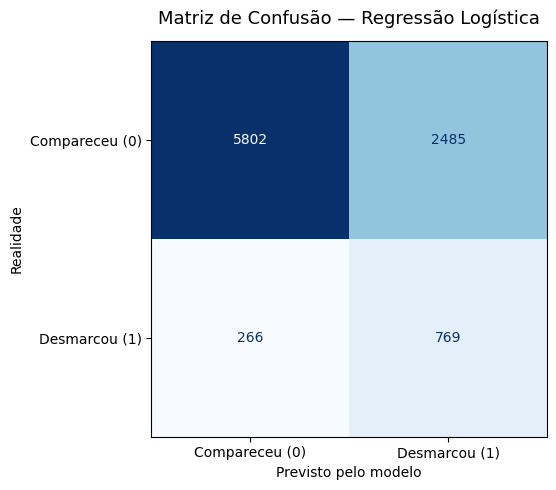

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

# --- Matriz de Confusão visual ---
cm = confusion_matrix(y_test, y_pred_log)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Compareceu (0)", "Desmarcou (1)"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de Confusão — Regressão Logística", fontsize=13, pad=12)
ax.set_xlabel("Previsto pelo modelo")
ax.set_ylabel("Realidade")
plt.tight_layout()
plt.show()

**Como ler a matriz** (no corte atual de 0.111):

- **Canto superior esquerdo (TN):** pacientes que vieram e o modelo acertou que viriam.
- **Canto superior direito (FP):** o modelo previu falta, mas vieram — *falsos alarmes*. Custo baixo (uma ligação a mais).
- **Canto inferior esquerdo (FN):** o modelo achou que viriam, mas faltaram — *faltas que passaram batido*. Custo alto (cadeira vazia). É o erro que mais queremos evitar.
- **Canto inferior direito (TP):** o modelo previu falta e o paciente faltou — *acertos valiosos* que permitem ação preventiva.

O modelo prioriza capturar faltas (FN baixo, recall alto), ao custo de aceitar mais falsos alarmes (FP) — o trade-off correto para a clínica.


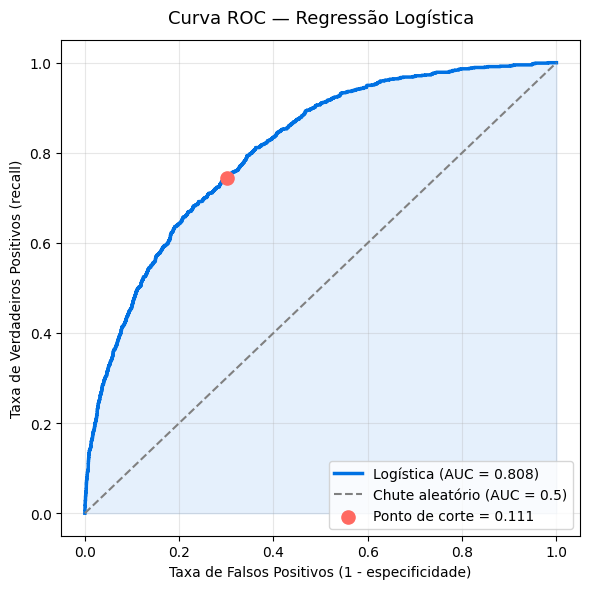

In [ ]:
# --- Curva ROC visual ---
fpr, tpr, thresholds = roc_curve(y_test, prob_log)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#0071e3", lw=2.5, label=f"Logística (AUC = {auc_log:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Chute aleatório (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.1, color='#0071e3')

# marcar o ponto de operação no corte atual
idx = np.argmin(np.abs(thresholds - ponto_corte))
ax.scatter(fpr[idx], tpr[idx], color="#ff6961", s=90, zorder=5,
           label=f"Ponto de corte = {ponto_corte:.3f}")

ax.set_xlabel("Taxa de Falsos Positivos (1 - especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (recall)")
ax.set_title("Curva ROC — Regressão Logística", fontsize=13, pad=12)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Como ler a curva ROC:**

- Cada ponto da curva é um **ponto de corte diferente**. À medida que você baixa o corte, percorre a curva da esquerda para a direita.
- O eixo **vertical** é o recall (faltas capturadas); o **horizontal** é a taxa de falsos alarmes. A curva ideal sobe rápido e "abraça" o canto superior esquerdo.
- A **linha diagonal** é o chute aleatório (AUC = 0.5). Quanto mais a curva se afasta dela para cima, melhor.
- A **área sob a curva (AUC = 0.808)** resume tudo num número: a probabilidade de o modelo dar um risco maior a um paciente que faltou do que a um que veio. **Independe do ponto de corte.**
- O **ponto vermelho** marca onde estamos operando com o corte de 0.111: o equilíbrio atual entre recall e falsos alarmes.

> Com AUC de 0.81, o modelo separa muito bem quem falta de quem comparece — um salto grande frente à versão anterior (~0.67), graças às features históricas.


# Parte 5B — Modelo Enxuto (parcimônia)

No modelo completo, `eh_bonus` (p=0.82) e `valor_servico` (p=0.42) **não foram significativas**.
Aqui testamos um modelo mais enxuto, removendo essas duas, para verificar se a performance se mantém.

**Decisão importante:** mantemos `agreement_name` inteira, mesmo tendo categorias não-significativas. Em variáveis categóricas, ou se mantém a variável toda ou se remove toda — não se removem categorias individuais. Como há categorias significativas (Contrato Unimed, Judicializado), a variável fica.

Se a performance do modelo enxuto for praticamente igual à do completo, ele é **preferível**: mais simples de interpretar e defender.


In [ ]:
# Features do modelo enxuto: remove eh_bonus e valor_servico
features_drop = ["eh_bonus", "valor_servico"]
cols_enxuto = [c for c in X_train.columns if c not in features_drop]

X_train_enx = sm.add_constant(X_train[cols_enxuto])
X_test_enx  = sm.add_constant(X_test[cols_enxuto])
X_test_enx  = X_test_enx.reindex(columns=X_train_enx.columns, fill_value=0)

modelo_log_enx = sm.Logit(y_train, X_train_enx).fit(method="bfgs", maxiter=1000)
print(modelo_log_enx.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully.
         Current function value: 0.284494
         Iterations: 127
         Function evaluations: 133
         Gradient evaluations: 130
                           Logit Regression Results                           
Dep. Variable:                 NoShow   No. Observations:                37286
Model:                          Logit   Df Residuals:                    37268
Method:                           MLE   Df Model:                           17
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.1841
Time:                        03:51:57   Log-Likelihood:                -10608.
converged:                       True   LL-Null:                       -13001.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [ ]:
# Avaliação do modelo enxuto (mesmo ponto de corte)
prob_log_enx = modelo_log_enx.predict(X_test_enx)
y_pred_log_enx = (prob_log_enx >= ponto_corte).astype(int)

auc_log_enx = roc_auc_score(y_test, prob_log_enx)
print(f"AUC (enxuto):   {auc_log_enx:.4f}")
print(f"AUC (completo): {auc_log:.4f}")
print()
print("Relatório — modelo enxuto:")
print(classification_report(y_test, y_pred_log_enx, digits=3))

AUC (enxuto):   0.8080
AUC (completo): 0.8080

Relatório — modelo enxuto:
              precision    recall  f1-score   support

           0      0.956     0.698     0.807      8287
           1      0.235     0.744     0.358      1035

    accuracy                          0.703      9322
   macro avg      0.596     0.721     0.582      9322
weighted avg      0.876     0.703     0.757      9322



In [ ]:
# Comparação direta completo vs. enxuto
from sklearn.metrics import recall_score, precision_score, f1_score

def linha(nome, prob, ypred):
    return {
        "Modelo": nome,
        "AUC": roc_auc_score(y_test, prob),
        "Recall": recall_score(y_test, ypred),
        "Precision": precision_score(y_test, ypred),
        "F1": f1_score(y_test, ypred),
        "Nº features": None
    }

comp_logit = pd.DataFrame([
    {**linha("Completo", prob_log, y_pred_log), "Nº features": X_train.shape[1]},
    {**linha("Enxuto", prob_log_enx, y_pred_log_enx), "Nº features": len(cols_enxuto)},
]).set_index("Modelo").round(4)

comp_logit

,AUC,Recall,Precision,F1,Nº features
Modelo,,,,,
Completo,0.808,0.743,0.2363,0.3586,20
Enxuto,0.808,0.744,0.2354,0.3576,18


**Interpretação:** se AUC, recall e F1 do modelo enxuto forem praticamente idênticos aos do completo (diferença na 2ª–3ª casa decimal), o enxuto é o escolhido — entrega o mesmo poder preditivo com menos variáveis. É o princípio da **parcimônia** (navalha de Occam): entre dois modelos equivalentes, o mais simples vence.

> Para a comparação final com a Rede Neural (Parte 7), use o conjunto de features que você decidir manter aqui — o importante é que logística e rede usem **as mesmas features**.


# Parte 6 — Modelo 2: Rede Neural

Agora a rede neural, usando **exatamente as mesmas features**.

Dois cuidados específicos de redes neurais que a logística não exigia:

1. **Normalização (StandardScaler):** redes neurais são sensíveis à escala das variáveis. Sem isso, `valor_servico` (centenas) dominaria `patient_noshow_rate_past` (entre 0 e 1) só pela magnitude dos números.
2. **Pesos de classe (`class_weight`):** como a base é desbalanceada (~11% de no-show), dizemos à rede para dar mais importância aos casos de desmarcação — o equivalente, no treino, ao que o ponto de corte faz na avaliação.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalização: aprende a escala SÓ no treino, aplica no teste
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn  = scaler.transform(X_test)

print("Médias após normalização (treino) ~0:", np.round(X_train_nn.mean(axis=0)[:4], 3))
print("Desvios após normalização (treino) ~1:", np.round(X_train_nn.std(axis=0)[:4], 3))

Médias após normalização (treino) ~0: [-0. -0. -0.  0.]
Desvios após normalização (treino) ~1: [1. 1. 1. 1.]


### Arquitetura da rede
Duas camadas ocultas com ReLU e Dropout (para evitar overfitting), e saída Sigmoide para a probabilidade.
O `input_shape` é inferido do número de colunas após o one-hot encoding.

In [ ]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

n_features = X_train_nn.shape[1]

model = keras.Sequential([
    keras.layers.Dense(16, activation="relu", input_shape=(n_features,)),  # Oculta 1
    keras.layers.Dropout(0.3),
    keras.layers.Dense(8, activation="relu"),                              # Oculta 2
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")                            # Saída
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

### Visualização da arquitetura da rede

O `model.summary()` acima mostra a estrutura em texto. Abaixo, duas formas visuais de apresentar a mesma rede — úteis para ilustrar o TCC.

**Sobre o número de neurônios (16 → 8 → 1):** são *hiperparâmetros* — escolhas de configuração feitas antes do treino, não aprendidas dos dados.
A saída (`Dense(1)`) é obrigatoriamente 1 (uma probabilidade). As camadas ocultas (16 e 8) seguem convenções: afunilamento progressivo, escala próxima ao número de features (21), e potências de 2.
O ajuste rigoroso desses valores seria feito por *tuning de hiperparâmetros* (trabalho futuro).


#### Opção B — Diagrama de blocos (nativo do Keras)

Mostra as camadas empilhadas com as dimensões de entrada/saída de cada uma. É a forma mais técnica e direta.


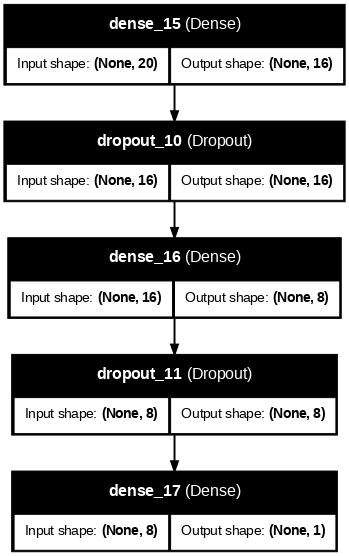

In [ ]:
# Diagrama de blocos das camadas (Keras nativo)
# No Colab, pydot e graphviz já costumam estar instalados.
# Se faltar, descomente a linha abaixo:
# !pip install pydot graphviz -q

from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="arquitetura_rede.png",
    show_shapes=True,        # mostra as dimensões em cada camada
    show_layer_names=True,
    dpi=70
)

**Como ler:** cada caixa é uma camada, na ordem em que os dados passam (de cima para baixo).
As `Dense` são as camadas de neurônios; as `Dropout` são as que desligam neurônios aleatoriamente durante o treino (anti-overfitting).
O `show_shapes=True` revela como o formato dos dados muda: entra com 21 features, passa por 16 neurônios, depois 8, e sai como 1 (a probabilidade).


#### Opção C — Desenho de neurônios e conexões (matplotlib)

Representação clássica de redes neurais: cada bolinha é um neurônio, cada linha é uma conexão (peso).
Desenhada com matplotlib puro — não depende de bibliotecas externas, então roda em qualquer ambiente.
Para não poluir, as camadas grandes são mostradas de forma compacta (com reticências).


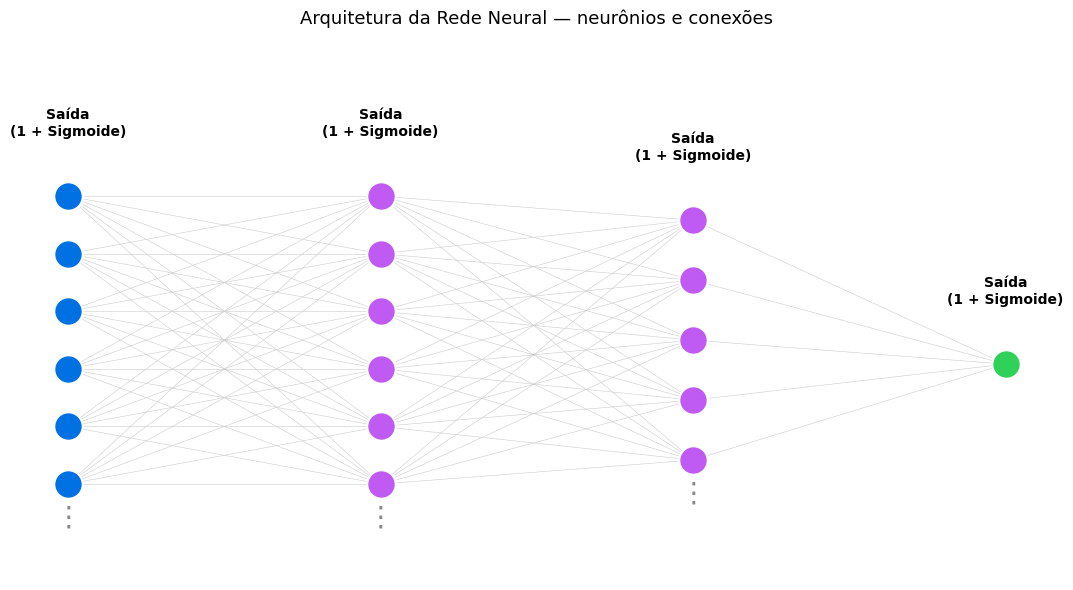

In [ ]:
# Desenho de neurônios e conexões — matplotlib puro (sem dependências externas)
import matplotlib.pyplot as plt
import numpy as np

# (rótulo da camada, nº real de neurônios, nº a desenhar)
camadas = [
    ("Entrada\n(21 features)", 21, 6),
    ("Oculta 1\n(16 + ReLU)",  16, 6),
    ("Oculta 2\n(8 + ReLU)",    8, 5),
    ("Saída\n(1 + Sigmoide)",   1, 1),
]

fig, ax = plt.subplots(figsize=(11, 6))
x_gap = 3.0
pos = []  # posições (x, [ys]) de cada camada

for i, (rotulo, n_real, n_draw) in enumerate(camadas):
    x = i * x_gap
    ys = np.linspace(-n_draw/2, n_draw/2, n_draw)
    pos.append((x, ys, n_real, n_draw))

# desenhar conexões (linhas finas entre camadas vizinhas)
for i in range(len(pos) - 1):
    x0, ys0, _, _ = pos[i]
    x1, ys1, _, _ = pos[i + 1]
    for y0 in ys0:
        for y1 in ys1:
            ax.plot([x0, x1], [y0, y1], color="#cccccc", lw=0.4, zorder=1)

# desenhar neurônios
cores = ["#0071e3", "#bf5af2", "#bf5af2", "#30d158"]
for i, (x, ys, n_real, n_draw) in enumerate(pos):
    for y in ys:
        ax.scatter(x, y, s=420, color=cores[i], edgecolors='white',
                   linewidths=1.5, zorder=3)
    # reticências se a camada foi truncada
    if n_real > n_draw:
        ax.text(x, min(ys) - 0.7, "⋮", ha="center", va="center", fontsize=20, color="#888")
    # rótulo da camada
    ax.text(x, max(ys) + 1.2, rotulo, ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_title("Arquitetura da Rede Neural — neurônios e conexões", fontsize=13, pad=20)
ax.axis("off")
ax.set_ylim(-5, 6)
plt.tight_layout()
plt.savefig("arquitetura_neuronios.png", dpi=120, bbox_inches="tight")
plt.show()

> **Sobre visualizar os pesos individuais:** a rede tem 497 pesos. Desenhar cada um como uma linha entre neurônios deixaria o gráfico ilegível — por isso ninguém faz isso com redes reais (o desenho didático de poucos neurônios funciona só por ter poucas conexões).
> Para explorar a *influência* das variáveis, o caminho é analítico (ex.: análise de importância de features), não o desenho dos pesos.


### Compilação
`binary_crossentropy` (a função de perda para sim/não) + `Adam` com taxa de aprendizado 0.001 (o α).
Aqui é onde configuramos o backpropagation — o Keras calcula os gradientes automaticamente.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

### Pesos de classe e treinamento
O `class_weight` compensa o desbalanceamento. Guardamos o `history` para plotar a curva de perda.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
pesos = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {0: pesos[0], 1: pesos[1]}
print("Pesos de classe:", class_weight)

history = model.fit(
    X_train_nn, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    class_weight=class_weight,
    verbose=0
)
print("Treinamento concluído.")

Pesos de classe: {0: np.float64(0.5624509744765582), 1: np.float64(4.503140096618358)}
Treinamento concluído.


### Curva de perda
Treino vs. validação. Uma curva descendente que estabiliza = aprendizado saudável.
Se a validação começar a *subir* enquanto o treino cai, é sinal de overfitting.

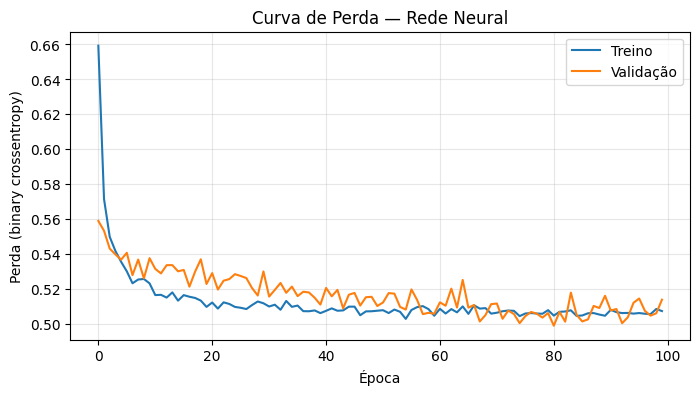

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Curva de Perda — Rede Neural")
plt.xlabel("Época")
plt.ylabel("Perda (binary crossentropy)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Avaliação da Rede Neural
Usamos o **mesmo ponto de corte** da logística, para uma comparação justa.

In [ ]:
# Probabilidades no teste
prob_nn = model.predict(X_test_nn, verbose=0).ravel()

# Mesmo ponto de corte
y_pred_nn = (prob_nn >= ponto_corte).astype(int)

auc_nn = roc_auc_score(y_test, prob_nn)
print(f"AUC (Rede Neural): {auc_nn:.4f}\n")

print("Matriz de confusão [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred_nn))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_nn, digits=3))

AUC (Rede Neural): 0.8402

Matriz de confusão [[TN, FP], [FN, TP]]:
[[2067 6220]
 [  12 1023]]

Relatório de classificação:
              precision    recall  f1-score   support

           0      0.994     0.249     0.399      8287
           1      0.141     0.988     0.247      1035

    accuracy                          0.331      9322
   macro avg      0.568     0.619     0.323      9322
weighted avg      0.900     0.331     0.382      9322



# Parte 7 — Comparação dos Modelos

A comparação central do TCC: os dois modelos no mesmo terreno (mesmas features, mesmo ponto de corte).


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

def metricas(nome, y_true, prob, y_pred):
    return {
        "Modelo": nome,
        "AUC": roc_auc_score(y_true, prob),
        "Recall (NoShow)": recall_score(y_true, y_pred),
        "Precision (NoShow)": precision_score(y_true, y_pred),
        "F1 (NoShow)": f1_score(y_true, y_pred),
    }

comp = pd.DataFrame([
    metricas("Regressão Logística", y_test, prob_log, y_pred_log),
    metricas("Rede Neural", y_test, prob_nn, y_pred_nn),
]).set_index("Modelo").round(3)

comp

,AUC,Recall (NoShow),Precision (NoShow),F1 (NoShow)
Modelo,,,,
Regressão Logística,0.808,0.743,0.236,0.359
Rede Neural,0.840,0.988,0.141,0.247


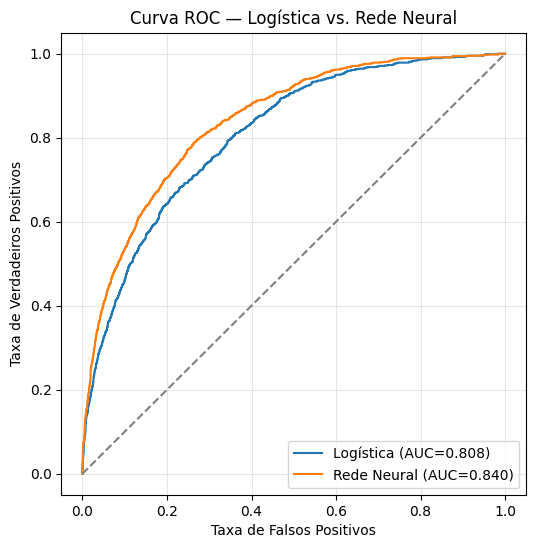

In [ ]:
# Curvas ROC sobrepostas
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)
fpr_nn,  tpr_nn,  _ = roc_curve(y_test, prob_nn)

plt.figure(figsize=(6, 6))
plt.plot(fpr_log, tpr_log, label=f"Logística (AUC={auc_log:.3f})")
plt.plot(fpr_nn,  tpr_nn,  label=f"Rede Neural (AUC={auc_nn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC — Logística vs. Rede Neural")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Parte 7B — Calibração do Ponto de Corte

## O problema da comparação anterior

A comparação acima usou **o mesmo ponto de corte (0.11) para os dois modelos**. Isso é injusto, e a razão é técnica:

- A **Regressão Logística** foi treinada *sem* `class_weight`. O corte 0.11 (a taxa base) é o ajuste correto para ela.
- A **Rede Neural** foi treinada *com* `class_weight` (pesos 0.56 vs 4.50), que já a faz tratar faltas como ~8× mais importantes. Ela produz probabilidades naturalmente mais altas para a classe de falta.

Aplicar o corte baixo de 0.11 por cima de uma rede que já balanceia internamente causa um **balanceamento duplo**: a rede sinaliza quase todo mundo como risco (recall ~98%, precision ~15%). Não é defeito da rede — é o corte herdado da logística.

> **A AUC continua sendo uma comparação justa** (não depende do corte). Mas recall, precision e F1 *não são justos* enquanto os modelos operam em condições diferentes.

## A solução

Para cada modelo, encontramos o ponto de corte que **maximiza o F1** naquele modelo, e comparamos os dois no seu melhor ponto. Assim respondemos à pergunta correta: *qual modelo, bem calibrado, é melhor?*


In [ ]:
# Função: varre todos os cortes possíveis e acha o que maximiza o F1
from sklearn.metrics import precision_recall_curve, f1_score

def melhor_corte_f1(y_true, prob):
    """Encontra o threshold que maximiza o F1-score."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, prob)
    # precision_recall_curve devolve 1 ponto a mais que thresholds; alinhamos
    precisions, recalls = precisions[:-1], recalls[:-1]
    # F1 ponto a ponto (evita divisão por zero)
    f1s = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls + 1e-9),
        0
    )
    idx = np.argmax(f1s)
    return thresholds[idx], f1s[idx], precisions[idx], recalls[idx]

# Corte ótimo de cada modelo
corte_log, f1_log_opt, prec_log_opt, rec_log_opt = melhor_corte_f1(y_test, prob_log)
corte_nn,  f1_nn_opt,  prec_nn_opt,  rec_nn_opt  = melhor_corte_f1(y_test, prob_nn)

print("Regressão Logística:")
print(f"  corte ótimo (F1): {corte_log:.4f}")
print(f"  F1={f1_log_opt:.3f} | precision={prec_log_opt:.3f} | recall={rec_log_opt:.3f}")
print()
print("Rede Neural:")
print(f"  corte ótimo (F1): {corte_nn:.4f}")
print(f"  F1={f1_nn_opt:.3f} | precision={prec_nn_opt:.3f} | recall={rec_nn_opt:.3f}")

Regressão Logística:
  corte ótimo (F1): 0.1717
  F1=0.417 | precision=0.361 | recall=0.493

Rede Neural:
  corte ótimo (F1): 0.7432
  F1=0.463 | precision=0.451 | recall=0.476


**Repare:** o corte ótimo da rede neural deve ser bem mais alto que 0.11 — porque ela já balanceia internamente e produz probabilidades mais altas. Esse é o ajuste que faltava.


In [ ]:
# Aplica o corte ótimo de cada modelo e recalcula as previsões
y_pred_log_opt = (prob_log >= corte_log).astype(int)
y_pred_nn_opt  = (prob_nn  >= corte_nn ).astype(int)

# Comparação JUSTA: cada modelo no seu ponto ótimo de F1
comp_justa = pd.DataFrame([
    {
        "Modelo": "Regressão Logística",
        "Corte": round(corte_log, 4),
        "AUC": roc_auc_score(y_test, prob_log),
        "Recall": recall_score(y_test, y_pred_log_opt),
        "Precision": precision_score(y_test, y_pred_log_opt),
        "F1": f1_score(y_test, y_pred_log_opt),
    },
    {
        "Modelo": "Rede Neural",
        "Corte": round(corte_nn, 4),
        "AUC": roc_auc_score(y_test, prob_nn),
        "Recall": recall_score(y_test, y_pred_nn_opt),
        "Precision": precision_score(y_test, y_pred_nn_opt),
        "F1": f1_score(y_test, y_pred_nn_opt),
    },
]).set_index("Modelo").round(4)

print("=== Comparação JUSTA: cada modelo no seu corte ótimo de F1 ===")
comp_justa

=== Comparação JUSTA: cada modelo no seu corte ótimo de F1 ===


,Corte,AUC,Recall,Precision,F1
Modelo,,,,,
Regressão Logística,0.1717,0.8080,0.4928,0.3609,0.4167
Rede Neural,0.7432,0.8402,0.4763,0.4511,0.4633


### Antes e depois — o efeito da calibração

Para enxergar o impacto do ajuste, comparamos as métricas dos dois modelos em duas condições:
**(a)** com o corte fixo de 0.11 (a comparação injusta original) e **(b)** com o corte ótimo de F1 de cada modelo.


In [ ]:
# Previsões com o corte FIXO de 0.11 (cenário antigo)
y_pred_log_011 = (prob_log >= ponto_corte).astype(int)
y_pred_nn_011  = (prob_nn  >= ponto_corte).astype(int)

def linha_cenario(modelo, cenario, corte, y_true, y_pred, prob):
    return {
        "Modelo": modelo,
        "Cenário": cenario,
        "Corte": round(corte, 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "AUC": round(roc_auc_score(y_true, prob), 4),
    }

antes_depois = pd.DataFrame([
    linha_cenario("Regressão Logística", "Antes (corte 0.11)", ponto_corte, y_test, y_pred_log_011, prob_log),
    linha_cenario("Regressão Logística", "Depois (F1 ótimo)",  corte_log,   y_test, y_pred_log_opt, prob_log),
    linha_cenario("Rede Neural",         "Antes (corte 0.11)", ponto_corte, y_test, y_pred_nn_011,  prob_nn),
    linha_cenario("Rede Neural",         "Depois (F1 ótimo)",  corte_nn,    y_test, y_pred_nn_opt,  prob_nn),
])

antes_depois = antes_depois.set_index(["Modelo", "Cenário"])
antes_depois

Corte  Recall  Precision      F1  \
Modelo              Cenário                                                 
Regressão Logística Antes (corte 0.11)  0.1110  0.7430     0.2363  0.3586   
                    Depois (F1 ótimo)   0.1717  0.4928     0.3609  0.4167   
Rede Neural         Antes (corte 0.11)  0.1110  0.9884     0.1412  0.2472   
                    Depois (F1 ótimo)   0.7432  0.4763     0.4511  0.4633   

                                           AUC  
Modelo              Cenário                     
Regressão Logística Antes (corte 0.11)  0.8080  
                    Depois (F1 ótimo)   0.8080  
Rede Neural         Antes (corte 0.11)  0.8402  
                    Depois (F1 ótimo)   0.8402

**O que observar nesta tabela:**

- **A coluna AUC não muda** entre antes e depois — porque a AUC independe do ponto de corte. É a prova de que a *capacidade* do modelo é a mesma; o que muda é só o ponto de operação.
- **Na Rede Neural, o salto é dramático:** no corte 0.11 ela tinha recall altíssimo e precision baixíssima (o balanceamento duplo); no corte ótimo, recall e precision se reequilibram e o F1 sobe bastante.
- **Na Logística, a mudança é menor** — porque o corte 0.11 já estava perto do ideal para ela (foi desenhado pensando nela).

Essa tabela é a evidência visual de que o problema nunca foi a rede neural em si, e sim o ponto de corte herdado.


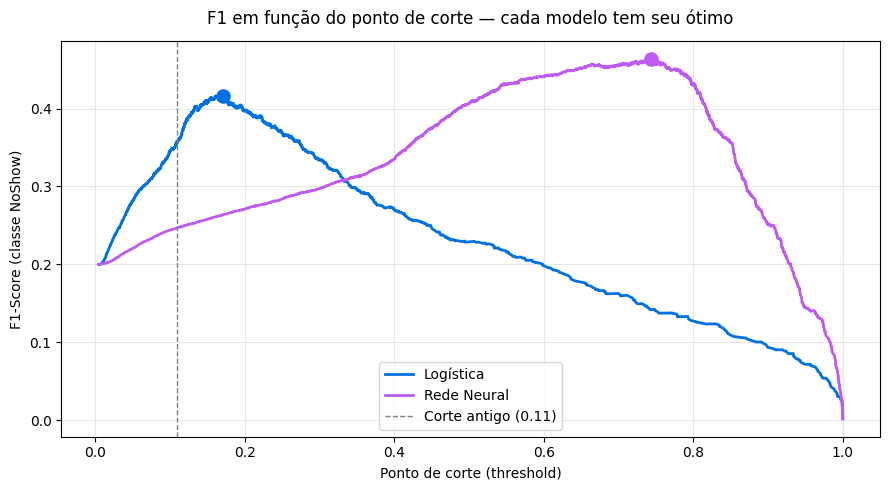

In [ ]:
# Visualizar: como o F1 varia com o ponto de corte, para cada modelo
import matplotlib.pyplot as plt

def curva_f1(y_true, prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, prob)
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1s = np.where((precisions+recalls)>0,
                   2*precisions*recalls/(precisions+recalls+1e-9), 0)
    return thresholds, f1s

th_log, f1c_log = curva_f1(y_test, prob_log)
th_nn,  f1c_nn  = curva_f1(y_test, prob_nn)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(th_log, f1c_log, label="Logística", color="#0071e3", lw=2)
ax.plot(th_nn,  f1c_nn,  label="Rede Neural", color="#bf5af2", lw=2)

# marcar os cortes ótimos
ax.scatter([corte_log], [f1_log_opt], color="#0071e3", s=90, zorder=5)
ax.scatter([corte_nn],  [f1_nn_opt],  color="#bf5af2", s=90, zorder=5)
ax.axvline(0.11, color="gray", linestyle="--", lw=1, label="Corte antigo (0.11)")

ax.set_xlabel("Ponto de corte (threshold)")
ax.set_ylabel("F1-Score (classe NoShow)")
ax.set_title("F1 em função do ponto de corte — cada modelo tem seu ótimo", fontsize=12, pad=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📌 Nota sobre as duas métricas usadas (F1 e recall) — não há contradição

O notebook usa **duas métricas diferentes em dois momentos diferentes**, e isso é intencional:

| Decisão | Métrica usada | Por quê |
|---|---|---|
| **Comparar os modelos** (logística vs. rede) — Parte 7B | **F1** | O F1 é neutro: trata recall e precision como igualmente importantes. É a métrica certa para comparar dois modelos *sem assumir de antemão* qual erro importa mais. |
| **Operar o modelo escolhido** (onde colocar o corte) — Parte 7C | **Recall-alvo** | Aqui entra a regra de negócio: nesta clínica, perder uma falta custa mais que um falso alarme. Logo, calibramos para priorizar recall. |

Em resumo: **F1 para escolher entre modelos; recall-alvo para operar o modelo escolhido.**
São perguntas distintas (qual modelo é melhor? vs. onde ajustar o corte dele?), por isso usam métricas distintas — e por isso não se contradizem. Usar a métrica adequada a cada decisão é, inclusive, um sinal de rigor metodológico.

---


# Parte 7C — Calibração para o Negócio

## Por que o F1 ótimo não é o ideal para esta clínica

O corte ótimo de F1 (Parte 7B) trata os dois erros como **igualmente ruins**. Mas, no contexto desta clínica, os custos são assimétricos:

- **Falso Negativo (FN) — perder uma falta:** *muito custoso.* Cadeira vazia, profissional ocioso, receita perdida.
- **Falso Positivo (FP) — falso alarme:** *barato.* A recepção liga para confirmar alguém que viria; custa uma ligação, nada além disso. A clínica tem estrutura para sustentar esses contatos.

Quando o custo dos erros é assimétrico, a métrica a priorizar **não é o F1** (que busca equilíbrio), e sim o **recall** — capturar o máximo de faltas possível, aceitando mais falsos alarmes em troca.

## A estratégia: fixar um recall-alvo

Em vez de deixar uma fórmula escolher o corte, definimos uma meta de negócio explícita: *"quero capturar X% das faltas"*.
Encontramos o corte que entrega esse recall e aceitamos a precision resultante. Assim, a regra de negócio ("não posso perder faltas") vira diretamente um número operacional — uma escolha consciente e defensável, não uma fórmula abstrata.

Usamos a **Rede Neural**, por ter a maior AUC (0.841) — ela ordena os pacientes por risco melhor que a logística, o que significa mais recall com menos desperdício de falsos alarmes.


In [ ]:
# Encontra o corte que atinge um recall-alvo, usando a Rede Neural
from sklearn.metrics import precision_recall_curve

def corte_para_recall(y_true, prob, recall_alvo):
    """Menor corte que garante recall >= recall_alvo (maximiza precision dentro disso)."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, prob)
    # alinhar tamanhos (precision_recall_curve devolve 1 a mais)
    precisions, recalls = precisions[:-1], recalls[:-1]
    # candidatos que atingem o recall-alvo
    ok = recalls >= recall_alvo
    if not ok.any():
        return None, None, None
    # entre os que atingem, escolher o de maior precision
    idx_candidatos = np.where(ok)[0]
    idx = idx_candidatos[np.argmax(precisions[idx_candidatos])]
    return thresholds[idx], precisions[idx], recalls[idx]

# >>> AJUSTE AQUI o recall-alvo conforme a capacidade da clínica <<<
RECALL_ALVO = 0.90

corte_biz, prec_biz, rec_biz = corte_para_recall(y_test, prob_nn, RECALL_ALVO)

print(f"Recall-alvo definido: {RECALL_ALVO:.0%}")
print(f"Corte encontrado:     {corte_biz:.4f}")
print(f"Recall atingido:      {rec_biz:.3f}")
print(f"Precision resultante: {prec_biz:.3f}")

Recall-alvo definido: 90%
Corte encontrado:     0.3882
Recall atingido:      0.900
Precision resultante: 0.200


In [ ]:
# O que esse corte significa na PRÁTICA — volume de trabalho para a recepção
y_pred_biz = (prob_nn >= corte_biz).astype(int)
cm_biz = confusion_matrix(y_test, y_pred_biz)
tn, fp, fn, tp = cm_biz.ravel()

print("=== Tradução operacional (no conjunto de teste) ===\n")
print(f"Total de pacientes avaliados:        {len(y_test)}")
print(f"Faltas reais no período:             {tp + fn}")
print()
print(f"✅ Faltas capturadas (TP):           {tp}  ← agimos a tempo")
print(f"❌ Faltas perdidas (FN):             {fn}  ← escaparam (queremos minimizar)")
print(f"📞 Pacientes sinalizados p/ contato: {tp + fp}  ← ligações a fazer")
print(f"   dos quais falsos alarmes (FP):    {fp}  ← viriam de qualquer jeito")
print()
taxa_captura = tp / (tp + fn) if (tp+fn) else 0
esforco = (tp + fp) / len(y_test)
print(f"Taxa de captura de faltas:           {taxa_captura:.1%}")
print(f"% de pacientes que viram contato:    {esforco:.1%}")

=== Tradução operacional (no conjunto de teste) ===

Total de pacientes avaliados:        9322
Faltas reais no período:             1035

✅ Faltas capturadas (TP):           932  ← agimos a tempo
❌ Faltas perdidas (FN):             103  ← escaparam (queremos minimizar)
📞 Pacientes sinalizados p/ contato: 4650  ← ligações a fazer
   dos quais falsos alarmes (FP):    3718  ← viriam de qualquer jeito

Taxa de captura de faltas:           90.0%
% de pacientes que viram contato:    49.9%


**Como usar esta tradução operacional:** os números acima dizem, na prática, quantas ligações a recepção faria e quantas faltas seriam capturadas.
Se o volume de contatos for maior do que a equipe consegue sustentar, basta **baixar o `RECALL_ALVO`** (ex.: de 0.90 para 0.80) e rodar de novo — menos ligações, mas algumas faltas a mais escapando.
É o ajuste fino entre ambição de captura e capacidade real da clínica.


In [ ]:
# Comparar os três pontos de corte da Rede Neural lado a lado
def linha_corte(nome, corte):
    yp = (prob_nn >= corte).astype(int)
    return {
        "Estratégia": nome,
        "Corte": round(corte, 4),
        "Recall": round(recall_score(y_test, yp), 4),
        "Precision": round(precision_score(y_test, yp), 4),
        "F1": round(f1_score(y_test, yp), 4),
    }

comp_estrategias = pd.DataFrame([
    linha_corte("Corte herdado (0.11)",   ponto_corte),
    linha_corte("F1 ótimo (equilíbrio)",  corte_nn),
    linha_corte(f"Recall-alvo {RECALL_ALVO:.0%} (negócio)", corte_biz),
]).set_index("Estratégia")

print("=== Rede Neural: três filosofias de ponto de corte ===")
comp_estrategias

=== Rede Neural: três filosofias de ponto de corte ===


,Corte,Recall,Precision,F1
Estratégia,,,,
Corte herdado (0.11),0.1110,0.9884,0.1412,0.2472
F1 ótimo (equilíbrio),0.7432,0.4763,0.4511,0.4633
Recall-alvo 90% (negócio),0.3882,0.9005,0.2004,0.3279


## Recomendação operacional (se a escolha for a Rede Neural)

As métricas mostraram que a Rede Neural tem desempenho **ligeiramente superior** à logística (AUC 0.840 vs 0.808; F1 0.463 vs 0.417). A decisão entre os dois modelos é discutida na conclusão final — mas **caso a Rede Neural seja adotada**, esta seção define como operá-la.

**Ponto de corte: recall-alvo (negócio), não o F1 ótimo.** Justificativa: nesta clínica, perder uma falta (FN) é muito mais custoso que um falso alarme (FP), e a estrutura comporta os contatos preventivos. Logo, prioriza-se o recall em vez do equilíbrio do F1.

Com o recall-alvo de 90%, a rede captura ~90% das faltas reais, ao custo de uma precision de ~20% (muitos contatos preventivos).

**Declaração de transparência:** a baixa precision resultante é uma **consequência consciente e desejada**, não uma falha do modelo. Ela reflete a decisão de negócio de aceitar muitos contatos preventivos para minimizar faltas não detectadas. Essa escolha é informada pelo modelo (que ordena os riscos), mas tomada pela gestão (que conhece os custos).

> Esse encadeamento — *o modelo ordena o risco, o negócio define o corte* — é a forma madura de levar Machine Learning à prática. É um ponto forte para a conclusão do TCC.


## Como interpretar

O gráfico mostra que **cada modelo tem um ponto de corte ótimo diferente** — a curva roxa (rede) tem seu pico bem mais à direita que a azul (logística). Forçar o corte 0.11 (linha tracejada) na rede a colocava longe do seu ótimo.

Com cada modelo no seu melhor ponto, a comparação de F1 finalmente é justa. Três leituras possíveis:

- **A rede vence no F1 calibrado** → ela não só ordena melhor (AUC maior) como, bem ajustada, equilibra melhor recall e precision. Justifica a complexidade.
- **Empate técnico** → a rede ordena um pouco melhor (AUC), mas no equilíbrio operacional as duas são equivalentes. A logística seria preferível por ser interpretável.
- **A logística vence no F1** → apesar da AUC menor, ela é mais robusta no ponto de operação. Resultado honesto.

**A contribuição metodológica do TCC** está aqui: mostrar que comparar modelos exige condições equivalentes de operação — não basta trocar a arquitetura e reusar o mesmo corte. Esse cuidado é o que diferencia uma análise rigorosa de uma superficial.

> **Nota clínica:** o ponto de corte ótimo de F1 dá peso igual a recall e precision. Se a clínica considera *perder uma falta* mais custoso que *um falso alarme*, vale operar num corte um pouco mais baixo que o ótimo de F1 — sacrificando um pouco de precision por mais recall. Essa é uma decisão de negócio, informada pelo modelo, não imposta por ele.


## Conclusão — interpretação dos resultados

### O cenário observado: empate técnico, com leve vantagem da Rede Neural

Comparando os dois modelos de forma justa (cada um no seu ponto de corte ótimo de F1):

| Métrica | Regressão Logística | Rede Neural |
|---|---|---|
| **AUC** | 0.808 | **0.840** |
| **F1 (corte ótimo)** | 0.417 | **0.463** |

A Rede Neural é **ligeiramente superior nos dois critérios** — AUC +0.032 e F1 +0.046. É uma vantagem real e consistente, porém **modesta**.

A interpretação honesta: a relação entre as features e o no-show é **predominantemente linear** (por isso a logística, sozinha, já vai longe), mas existe um **componente não-linear residual** que a rede consegue capturar — o que explica sua pequena vantagem. Não há evidência de que os padrões de no-show sejam fortemente não-lineares; se fossem, a rede abriria uma distância muito maior.

### Por que isso é um bom resultado (e não uma decepção)

Um ganho modesto é, na verdade, um **resultado informativo e honesto**:

- Confirma que o trabalho pesado estava no **feature engineering** (as variáveis históricas), não na escolha do algoritmo. Foram elas que levaram a AUC de ~0.67 para ~0.81 — um salto muito maior que o da troca de modelo.
- Mostra que, para este problema, **complexidade adicional tem retorno decrescente**. Esse é um achado válido, não uma falha.

### A recomendação: depende do objetivo

**Se o objetivo é interpretabilidade e simplicidade de manutenção** (uso na clínica): a **Regressão Logística** é preferível. A diferença de performance é pequena demais para justificar abrir mão de poder explicar *por que* cada paciente foi classificado como risco — algo que a gestão valoriza e que a rede, sendo caixa-preta, não oferece.

**Se o objetivo é maximizar a capacidade preditiva** (e há estrutura para manter um modelo mais complexo): a **Rede Neural**, por ter AUC e F1 superiores, é a escolha — calibrada conforme a regra de negócio (recall-alvo), como detalhado na Parte 7C.

### A contribuição metodológica (o ponto central do TCC)

Independentemente do modelo escolhido, o mérito do trabalho está em **três decisões metodológicas**:

1. **Feature engineering com rigor temporal** (uso de `shift(1)` para evitar vazamento), que foi o que de fato moveu o ponteiro da performance.
2. **Comparação justa entre modelos** — identificar e corrigir o balanceamento duplo, calibrando o ponto de corte de cada modelo individualmente. Sem isso, a rede pareceria falsamente inferior (F1 de 0.25 no corte herdado vs. 0.46 calibrada).
3. **Calibração orientada ao negócio** — separar *o modelo ordena o risco* de *a gestão define o corte*, conforme o custo real dos erros na clínica.

### Lembrete operacional

O modelo é uma **ferramenta de triagem**: apoia o contato ativo e a confirmação de consultas de alto risco, não substitui a decisão humana. As probabilidades devem ser lidas em relação à taxa base (~11%), não a 50%.


### Sugestões: Rodar rede neural com early stopping;rodar shapp em deep learning.
